# 3. From individual binaries to a population

**FQCP 2026 · Bayesian parameter estimation for compact binaries**

> Self-contained and designed for Google Colab. Run top to bottom; **Extension** cells may be skipped live.


## Goal

See why the detected catalogue is not the astrophysical population.

\[
p(\Lambda\mid\{d_i\},\mathrm{det})\propto p(\Lambda)
\prod_i\frac{\int p(d_i\mid\theta)p(\theta\mid\Lambda)d\theta}{\alpha(\Lambda)}.
\]

For clarity, masses are treated as exactly measured and only a population mean is inferred.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["animation.html"] = "jshtml"
print("Running in Colab:", IN_COLAB)

Running in Colab: False


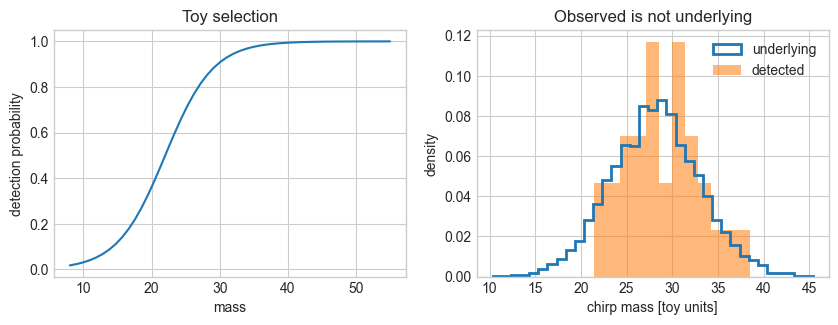

underlying mean 28.08 detected mean 29.04


In [2]:
from scipy.stats import norm
true_mean,true_width=28.,5.
all_masses=rng.normal(true_mean,true_width,5000)
all_masses=all_masses[(all_masses>8)&(all_masses<55)]
def p_detect(mass): return 1/(1+np.exp(-(mass-22)/3.5))
detected=all_masses[rng.random(all_masses.size)<p_detect(all_masses)][:30]
fig,axes=plt.subplots(1,2,figsize=(10,3.2)); grid=np.linspace(8,55)
axes[0].plot(grid,p_detect(grid)); axes[0].set(xlabel="mass",ylabel="detection probability",title="Toy selection")
axes[1].hist(all_masses,bins=35,density=True,histtype="step",lw=2,label="underlying")
axes[1].hist(detected,bins=12,density=True,alpha=.55,label="detected")
axes[1].set(xlabel="chirp mass [toy units]",ylabel="density",title="Observed is not underlying"); axes[1].legend(); plt.show()
print("underlying mean",round(all_masses.mean(),2),"detected mean",round(detected.mean(),2))

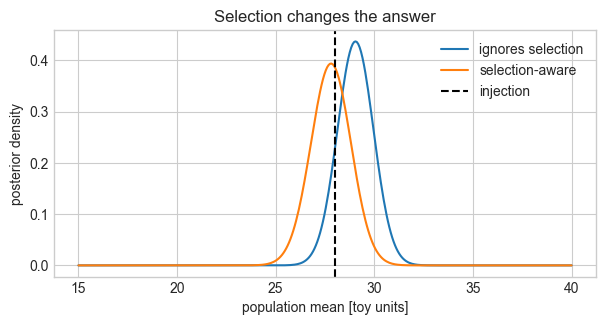

In [3]:
mean_grid=np.linspace(15,40,350); integration_grid=np.linspace(8,55,800)
log_naive=[]; log_corrected=[]
for mean in mean_grid:
    event_term=norm.logpdf(detected,mean,true_width).sum()
    alpha=np.trapezoid(norm.pdf(integration_grid,mean,true_width)*p_detect(integration_grid),integration_grid)
    log_naive.append(event_term); log_corrected.append(event_term-len(detected)*np.log(alpha))
def normalise(log_density):
    density=np.exp(log_density-np.max(log_density)); return density/np.trapezoid(density,mean_grid)
fig,ax=plt.subplots(figsize=(7,3.2))
ax.plot(mean_grid,normalise(np.array(log_naive)),label="ignores selection")
ax.plot(mean_grid,normalise(np.array(log_corrected)),label="selection-aware")
ax.axvline(true_mean,color="k",ls="--",label="injection")
ax.set(xlabel="population mean [toy units]",ylabel="posterior density",title="Selection changes the answer"); ax.legend(); plt.show()

## Check

<details><summary>Why divide by alpha once per event?</summary>

Conditioning each observed event on detection renormalises its population density by the detectable fraction. For a fixed observed count this contributes `alpha(Lambda)^(-N)`.

</details>

Real analyses integrate event likelihoods/posterior samples, infer several hyperparameters, estimate selection with injections, and often include the rate.